In [226]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import math


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dropout, LSTM, Dense, Layer, LayerNormalization, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping

import yfinance as yf




In [227]:
def scale_input(ticker, df):
    if ticker not in feature_scalers:
        print("Can Not Scale. Scaler Does Not Exist")
        return
    
    return feature_scalers[ticker].fit_transform(df)


def output_inverse_scale(ticker, value):
    if ticker not in target_scalers:
        print("Can Not Inverse. Scaler Does Not Exist")
        return

    return target_scalers[ticker].inverse_transform(np.array(value).reshape(-1, 1))


def save_model_weights(model, file_name, folder_name):
    os.makedirs(folder_name, exist_ok=True)

    words = file_name.split(".")

    model_name = words[0]

    existing_files = [f for f in os.listdir(folder_name) if f.startswith(model_name)]
    next_number = len(existing_files) + 1
    words[0] = f"{model_name}_{next_number}"

    file_name = ".".join(words)
    save_path = os.path.join(folder_name, file_name)

    model.save_weights(save_path)
    print(f"model saved to: {save_path}")


In [228]:
def plot_dataframe(df, columns = ['Open', 'Yesterday_Volume']):
    plt.figure(figsize=(15, 6)) 

    for col in columns:
        plt.plot(df.index, df[col], label=col, alpha=0.7)

    plt.title("All Columns Over Time (Scaled)")
    plt.xlabel("Time / Index")
    plt.ylabel("Scaled Value")
    
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) 
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [229]:
def apply_ssa_trend(series, window = 15, lookback = 60):
    n_total = len(series)
    result = np.zeros(n_total)
    
    result[:lookback] = series[:lookback]
    
    for t in range(lookback, n_total):
        sub_series = series[t - lookback + 1 : t + 1]
        
        N = len(sub_series)
        L = window
        K = N - L + 1
        X = np.column_stack([sub_series[i:i+L] for i in range(K)])
        
        U, Sigma, VT = np.linalg.svd(X, full_matrices=False)
        
        X1 = Sigma[0] * np.outer(U[:, 0], VT[0, :])
        
        n = N - 1
        vals = [X1[i, n-i] for i in range(max(0, n-K+1), min(n+1, L))]
        result[t] = np.mean(vals)
        
    return result

In [230]:
# Period must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
def get_dataset_columns(ticker, period = "1y", lookback = 60):
    df = yf.Tickers(ticker).history(period = period)
    # vix_data = yf.Tickers("^VIX").history(period = period, progress=False)
    df.columns = df.columns.droplevel(1)
    # vix_data.columns = vix_data.columns.droplevel(1)
    df = df.ffill().dropna()

    df = df.drop(['Stock Splits', 'Dividends'], axis=1)
    # df['Open_VIX'] = vix_data['Open']
    # df['Yesterday_VIX'] = vix_data['Close'].shift(1)
    # df['Yesterday_High'] = df['High'].shift(1)
    # df['Yesterday_Low'] = df['Low'].shift(1)
    # df['Yesterday_Volume'] = df['Volume'].shift(1)
    df['Yesterday_Close'] = df['Close'].shift(1)
    df['Close_Trend'] = apply_ssa_trend(df['Yesterday_Close'].values, window=15, lookback=lookback)
    df['Trend_Diff'] = df['Yesterday_Close'] - df['Close_Trend']

    # df['Target'] = ((df['Close'] - df['Yesterday_Close'])  * 100 / df['Yesterday_Close'])
    df['Target'] = np.log(df['Close'] / df['Yesterday_Close']) * 100
    # df['Target'] = df['Close']
    df = df.drop(df.index[0])
    
    df = df.drop(['High', 'Low', 'Volume', 'Close'], axis=1)

    feature_cols = ["Open", "Yesterday_Close", "Close_Trend", "Trend_Diff"]
    target_col = ["Target"]

    return df[lookback:], feature_cols, target_col

def scale_dataset(df, ticker, feature_cols, target_col, test_size=0.2, scale_target=False):
    train_size = int(len(df) * (1 - test_size))
    df_train = df.iloc[:train_size]

    if ticker not in feature_scalers:
        f_scaler = StandardScaler()
        f_scaler.fit(df_train[feature_cols])
        feature_scalers[ticker] = f_scaler

        if scale_target:
            t_scaler = StandardScaler()
            t_scaler.fit(df_train[target_col]) 
            target_scalers[ticker] = t_scaler

    df[feature_cols] = feature_scalers[ticker].transform(df[feature_cols])
    if scale_target:
        df[target_col] = target_scalers[ticker].transform(df[target_col])

    data_x = df[feature_cols].values
    data_y = df[target_col].values

    return data_x, data_y    

In [231]:
def get_full_dataset(tickers, period="1y", window_size=60, test_size=0.2):
    X_total, y_total = [], []
    
    for ticker in tickers:
        df, feature_cols, target_col = get_dataset_columns(ticker, period=period, lookback=window_size)
        data_x, data_y = scale_dataset(df, ticker, feature_cols, target_col, test_size)
        
        for i in range(len(df) - window_size):
            X_total.append(data_x[i : i + window_size])
            y_total.append(data_y[i + window_size])

    X_data = np.array(X_total)
    y_data = np.array(y_total)

    nan_mask = np.isnan(X_data).any(axis=(1, 2))
    X_data = X_data[~nan_mask]
    y_data = y_data[~nan_mask] 

    print(f"NaN Deleted: {np.sum(nan_mask)}")
    
    test_first_index = int(len(X_data) * (1 - test_size))
    X_train, X_test = X_data[:test_first_index], X_data[test_first_index:]
    y_train, y_test = y_data[:test_first_index], y_data[test_first_index:]

    print("""
    X_train Shape : {}
    X_test Shape : {}
    y_train Shape : {}
    y_test Shape : {}
    """.format(X_train.shape, X_test.shape, y_train.shape, y_test.shape))
    
    return X_train, X_test, y_train, y_test

In [232]:
google_df = get_dataset_columns("GOOG", period = "6y")
google_df

[*********************100%***********************]  1 of 1 completed


(Price             Open  Yesterday_Close  Close_Trend  Trend_Diff    Target
 Date                                                                      
 2020-05-18   67.580639        68.148369    67.124546    1.023823  0.779814
 2020-05-19   68.833586        68.681877    67.802907    0.878970 -0.758333
 2020-05-20   68.961771        68.163010    68.400347   -0.237338  2.390951
 2020-05-21   69.875918        69.812393    68.927811    0.884582 -0.279053
 2020-05-22   69.315627        69.617851    69.336320    0.281531  0.541744
 ...                ...              ...          ...         ...       ...
 2026-02-12  312.350006       311.329987   333.562056  -22.232070 -0.631544
 2026-02-13  307.984985       309.369995   331.320221  -21.950226 -1.088753
 2026-02-17  300.640015       306.019989   329.197909  -23.177920 -1.051183
 2026-02-18  302.432007       302.820007   326.487377  -23.667370  0.369173
 2026-02-19  302.519989       303.940002   323.826084  -19.886081 -0.125105
 
 [1447 row

In [233]:
google_df[0]

Price,Open,Yesterday_Close,Close_Trend,Trend_Diff,Target
Date,,,,,
2020-05-18,67.580639,68.148369,67.124546,1.023823,0.779814
2020-05-19,68.833586,68.681877,67.802907,0.878970,-0.758333
2020-05-20,68.961771,68.163010,68.400347,-0.237338,2.390951
2020-05-21,69.875918,69.812393,68.927811,0.884582,-0.279053
2020-05-22,69.315627,69.617851,69.336320,0.281531,0.541744
...,...,...,...,...,...
2026-02-12,312.350006,311.329987,333.562056,-22.232070,-0.631544
2026-02-13,307.984985,309.369995,331.320221,-21.950226,-1.088753
2026-02-17,300.640015,306.019989,329.197909,-23.177920,-1.051183


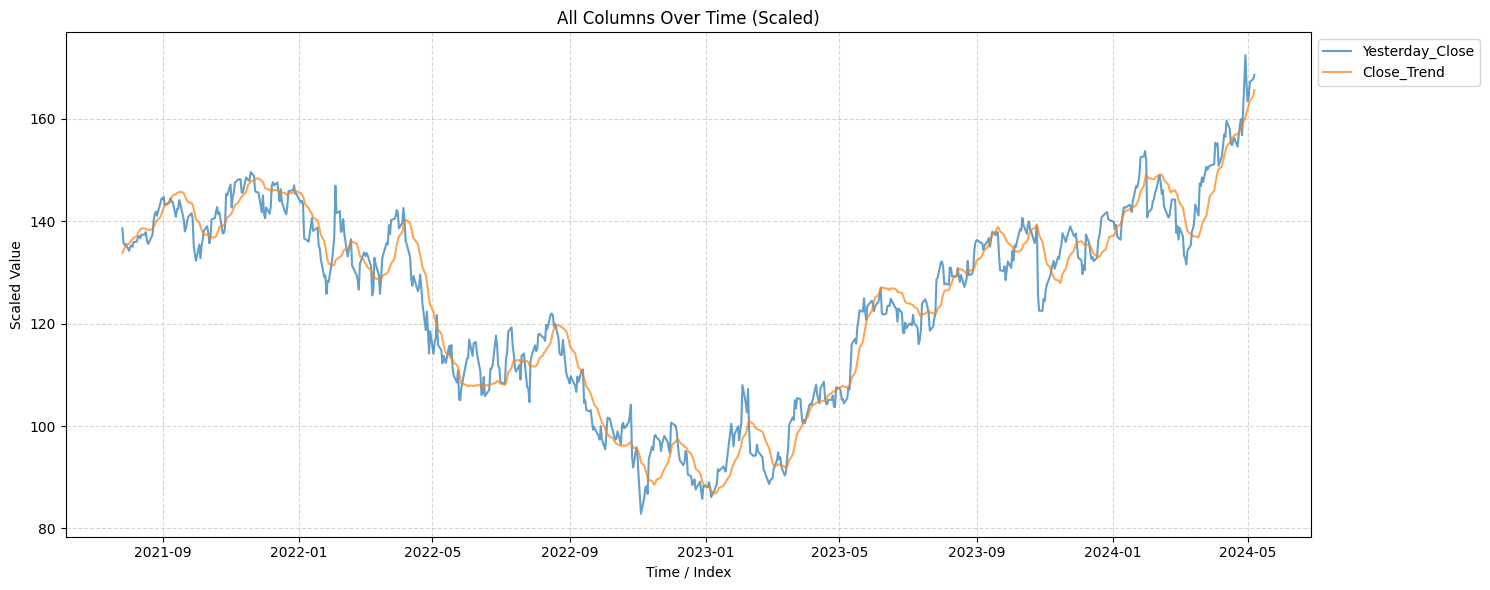

In [234]:
plot_dataframe(google_df[0][300:1000], columns = ['Yesterday_Close', 'Close_Trend'])

# Period must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
def get_dataset(ticker, period="1y"):
    df = yf.Tickers(ticker).history(period = period)
    vix_data = yf.Tickers("^VIX").history(period = period, progress=False)
    df.columns = df.columns.droplevel(1)
    vix_data.columns = vix_data.columns.droplevel(1)
    df = df.ffill().dropna()

    df = df.drop(['Stock Splits', 'Dividends'], axis=1)
    df['Open_VIX'] = vix_data['Open']
    df['Yesterday_VIX'] = vix_data['Close'].shift(1)
    df['Yesterday_High'] = df['High'].shift(1)
    df['Yesterday_Low'] = df['Low'].shift(1)
    df['Yesterday_Volume'] = df['Volume'].shift(1)
    df['Yesterday_Close'] = df['Close'].shift(1)
    # df['Return'] = ((df['Close'] - df['Yesterday_Close'])  * 100 / df['Yesterday_Close'])
    df['Return'] = np.log(df['Close'] / df['Yesterday_Close']) * 100
    # df['Return'] = df['Close']
    df = df.drop(df.index[0])
    
    df = df.drop(['High', 'Low', 'Volume', 'Close'], axis=1)

    return df


feature_scalers = {}
target_scalers = {}

def get_full_dataset(tickers, period="1mo", window_size=60, test_size=0.2):
    X_total, y_total = [], []
    
    for ticker in tickers:
        df = get_dataset(ticker, period)
        # feature_cols = ['Open', 'Yesterday_High', 'Yesterday_Low', 'Yesterday_Volume', 'Yesterday_Close', 'Open_VIX', 'Yesterday_VIX']
        feature_cols = ['Open', 'Yesterday_High', 'Yesterday_Low', 'Yesterday_Volume', 'Open_VIX', 'Yesterday_VIX']
        target_col = ['Target']

        train_size = int(len(df) * (1 - test_size))
        df_train = df.iloc[:train_size]

        if ticker not in feature_scalers:
            f_scaler = StandardScaler()
            f_scaler.fit(df_train[feature_cols])
            feature_scalers[ticker] = f_scaler
            
            # t_scaler = StandardScaler()
            # t_scaler.fit(df_train[target_col]) 
            # target_scalers[ticker] = t_scaler

        df[feature_cols] = feature_scalers[ticker].transform(df[feature_cols])
        # df[target_col] = target_scalers[ticker].transform(df[target_col])

        data_x = df[feature_cols].values
        data_y = df[target_col].values
        
        for i in range(len(df) - window_size):
            X_total.append(data_x[i : i + window_size])
            y_total.append(data_y[i + window_size])

    X_data = np.array(X_total)
    y_data = np.array(y_total)

    nan_mask = np.isnan(X_data).any(axis=(1, 2))
    X_data = X_data[~nan_mask]
    y_data = y_data[~nan_mask] 

    print(f"NaN Deleted: {np.sum(nan_mask)}")
    
    test_first_index = int(len(X_data) * (1 - test_size))
    X_train, X_test = X_data[:test_first_index], X_data[test_first_index:]
    y_train, y_test = y_data[:test_first_index], y_data[test_first_index:]

    print("""
    X_train Shape : {}
    X_test Shape : {}
    y_train Shape : {}
    y_test Shape : {}
    """.format(X_train.shape, X_test.shape, y_train.shape, y_test.shape))
    
    return X_train, X_test, y_train, y_test

In [235]:
tickers_5 = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]
tickers_20 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", 
    "TSM", "AVGO", "ASML",
    "JPM", "BAC", "V", "MA",
    "JNJ", "LLY", "UNH", "PG", "KO", "PEP"
]
tickers_50 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "TSLA", "NFLX", "ADBE", "CRM", "ORCL",
    "NVDA", "TSM", "AVGO", "ASML", "AMD", "INTC", "QCOM", "TXN", "MU", "AMAT",
    "JPM", "BAC", "V", "MA", "GS", "MS", "AXP", "PYPL", "WFC", "BLK",
    "JNJ", "LLY", "UNH", "PFE", "ABBV", "MRK", "TMO", "DHR", "AMGN", "ISRG",
    "PG", "KO", "PEP", "WMT", "COST", "NKE", "MCD", "HD", "DIS", "SBUX"
]

window_size = 60

X_train, X_test, y_train, y_test = get_full_dataset(
    tickers_20,
    period = "6y",
    window_size = window_size, 
    test_size = 0.2
)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

NaN Deleted: 0

    X_train Shape : (22192, 60, 4)
    X_test Shape : (5548, 60, 4)
    y_train Shape : (22192, 1)
    y_test Shape : (5548, 1)
    


In [236]:
pd.DataFrame(y_train).describe()

,0
count,22192.000000
mean,0.089379
std,2.261418
min,-30.639053
25%,-0.965830
50%,0.096617
75%,1.157333
max,21.859435


In [237]:
def get_LSTM_model(window_size=60, feature_num=7):
    dropout_rate = 0.2
    input_layer = Input(shape = (window_size, feature_num), name="Input")
    batch_norm_layer = BatchNormalization(name="BatchNormalization_1")(input_layer)
    LSTM_layer = LSTM(64, return_sequences=True, name = "LSTM_1")(batch_norm_layer)
    hidden_layer = Dropout(dropout_rate, name = f"Dropout_1_{dropout_rate}")(LSTM_layer)
    hidden_layer = BatchNormalization(name="BatchNormalization_2")(hidden_layer)
    hidden_layer = LSTM(32, return_sequences=True, name = "LSTM_2")(hidden_layer)
    hidden_layer = Dropout(dropout_rate, name = f"Dropout_2_{dropout_rate}")(hidden_layer)
    hidden_layer = Dense(16, activation = "relu", name="Dense")(hidden_layer)
    output_layer = Dense(1, activation = "linear", name="Output")(hidden_layer)

    model = Model(inputs = input_layer, outputs = output_layer, name='LSTM_BatchNorm_Dropout0.2_3y_window30')

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    # loss_fn = tf.keras.losses.Huber()
    model.compile(optimizer = optimizer, loss = 'mse', metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])
    return model

def directional_accuracy(y_true, y_pred):
    is_same_sign = tf.equal(tf.sign(y_true), tf.sign(y_pred))
    return tf.reduce_mean(tf.cast(is_same_sign, tf.float32))

In [240]:
earlyStopping_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.005,
    patience=5,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
)

feature_num = 4
LSTM_model = get_LSTM_model(window_size, feature_num)
LSTM_model.summary()

Model: "LSTM_BatchNorm_Dropout0.2_3y_window30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 60, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_1            │ (None, 60, 4)          │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_1 (LSTM)                   │ (None, 60, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1_0.2 (Dropout)         │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_2            │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 60, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2_0.2 (Dropout)         │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (None, 60, 16)         │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 60, 1)          │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,897 (120.69 KB)

 Trainable params: 30,761 (120.16 KB)

 Non-trainable params: 136 (544.00 B)

In [241]:
LSTM_model.fit(
    X_train, 
    y_train, 
    epochs = 50, 
    batch_size = 32,
    validation_data = (X_test, y_test),
    callbacks = [earlyStopping_callback]
)

Epoch 1/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - loss: 5.1322 - mae: 1.5419 - root_mean_squared_error: 2.2654 - val_loss: 1.8705 - val_mae: 0.9009 - val_root_mean_squared_error: 1.3677
Epoch 2/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 5.1201 - mae: 1.5393 - root_mean_squared_error: 2.2628 - val_loss: 1.8699 - val_mae: 0.9004 - val_root_mean_squared_error: 1.3674
Epoch 3/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 5.1166 - mae: 1.5382 - root_mean_squared_error: 2.2620 - val_loss: 1.8731 - val_mae: 0.9009 - val_root_mean_squared_error: 1.3686
Epoch 4/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 5.1149 - mae: 1.5377 - root_mean_squared_error: 2.2616 - val_loss: 1.8724 - val_mae: 0.9003 - val_root_mean_squared_error: 1.3684
Epoch 5/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 5.1134 - mae: 1.5374 - root_mean_squared_error: 2.2613 - val_loss: 1.8712 - val_mae: 0.9000 - val_root_mean_squared_error: 1.3679
Epoch 6/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 

In [242]:
save_model_weights(LSTM_model, "LSTM_TEST.weights.h5", "models")

model saved to: models/LSTM_TEST_13.weights.h5


In [243]:
def interpret_mae_to_percentage(mae_value):
    log_error = mae_value / 100
    price_ratio = 10**log_error
    percentage_error = (price_ratio - 1) * 100
    return percentage_error

In [244]:
loss, mae, rmse = LSTM_model.evaluate(X_test, y_test)

print(f"loss: {loss}")
print(f"mae: {mae}")
print(f"rmse: {rmse}")
# print(f"Binay Accuracy: {round(bidirection_acc * 100, 2)}%")

# print(f"Interpret mae: {round(interpret_mae_to_percentage(mae), 2)}%")

# print(f"mae scaled: {output_inverse_scale("GOOG", mae)}")

174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8705 - mae: 0.9009 - root_mean_squared_error: 1.3677
loss: 1.8704692125320435
mae: 0.9009121060371399
rmse: 1.3676509857177734


In [ ]:
# def predict_and_plot(ticker, period="1mo"):
#     df = get_dataset(ticker, period)
#     feature_cols = ['Open', 'Yesterday_High', 'Yesterday_Low', 'Yesterday_Volume', 'Open_VIX', 'Yesterday_VIX']
#     target_col = ['Return']

#     train_size = int(len(df) * (1 - test_size))
#     df_train = df.iloc[:train_size]

#     if ticker not in feature_scalers:
#             f_scaler = StandardScaler()
#             f_scaler.fit(df_train[feature_cols])
#             feature_scalers[ticker] = f_scaler
            
#             t_scaler = StandardScaler()
#             t_scaler.fit(df_train[target_col]) 
#             target_scalers[ticker] = t_scaler
    

174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Pred shape: (5548,)
True shape: (5548,)


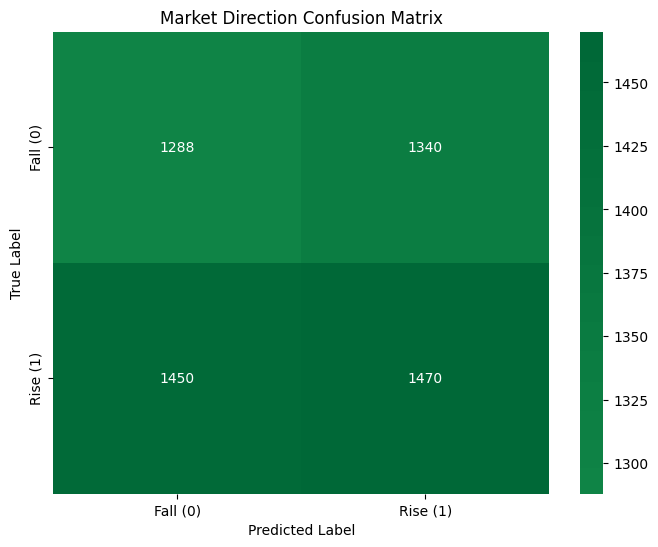


Classification Report:
              precision    recall  f1-score   support

        Fall       0.47      0.49      0.48      2628
        Rise       0.52      0.50      0.51      2920

    accuracy                           0.50      5548
   macro avg       0.50      0.50      0.50      5548
weighted avg       0.50      0.50      0.50      5548



In [251]:
predictions = LSTM_model.predict(X_test)

y_test_sign = (y_test > 0).astype(int)
pred_sign = (predictions > 0).astype(int)

pred_sign_final = pred_sign[:, -1, :].flatten()
y_test_final = y_test_sign.flatten()

print(f"Pred shape: {pred_sign_final.shape}")
print(f"True shape: {y_test_final.shape}") 

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_final, pred_sign_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', center=0,
            xticklabels=['Fall (0)', 'Rise (1)'], 
            yticklabels=['Fall (0)', 'Rise (1)'])

plt.title('Market Direction Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_final, pred_sign_final, target_names=['Fall', 'Rise']))

In [ ]:
pd.DataFrame(predictions).describe()

,0
count,5792.000000
mean,0.071417
std,0.109833
min,-0.274889
25%,0.014094
50%,0.070469
75%,0.149087
max,0.407791


      Actual  Predicted  Correct_Direction
0   2.107267   0.138138               True
1  -0.232977   0.132843              False
2   0.675768   0.124448               True
3  -0.990391   0.117377              False
4  -1.161132   0.110505              False
5  -0.446064   0.107014              False
6  -0.658489   0.107771              False
7   0.258190   0.111312               True
8  -1.701550   0.117343              False
9   1.088479   0.123307               True
10 -1.094961   0.132052              False
11  0.918653   0.138740               True
12  0.862606   0.146012               True
13 -0.580655   0.149796              False
14  0.089545   0.150894               True
15  2.341055   0.152912               True
16 -1.260054   0.154211              False
17 -1.346668   0.150141              False
18 -1.534137   0.149872              False
19  1.540542   0.152371               True
20 -2.406783   0.157177              False
21 -0.618335   0.158135              False
22  2.32448

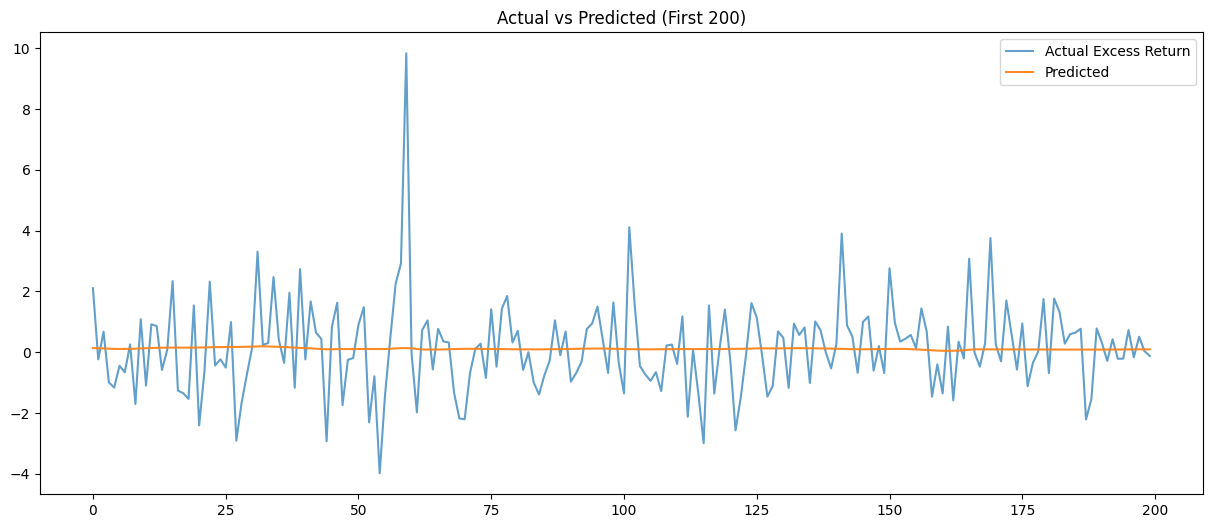

In [253]:
y_test_flat = y_test.flatten()
preds_flat = predictions[:, -1, :].flatten()

comparison_df = pd.DataFrame({
    'Actual': y_test_flat,
    'Predicted': preds_flat
})

comparison_df['Correct_Direction'] = (
    (comparison_df['Actual'] > 0) == (comparison_df['Predicted'] > 0)
)

print(comparison_df.head(50))

plt.figure(figsize=(15, 6))
plt.plot(comparison_df['Actual'][0:200], label='Actual Excess Return', alpha=0.7)
plt.plot(comparison_df['Predicted'][0:200], label='Predicted', alpha=0.9)

# x = range(100)
# actual = comparison_df['Actual'][:100]
# predicted = comparison_df['Predicted'][:100]

# plt.vlines(x, actual, predicted, color='red', alpha=0.4, label='Error (Difference)')

plt.title('Actual vs Predicted (First 200)')
# plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.legend()
plt.show()